<a href="https://colab.research.google.com/github/mp1605/CS-4410-Intro-to-Machine-Learning-/blob/main/Homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 15.17 — Binary Classification with the Breast Cancer Dataset


## 1. Importing


In [16]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)

Python: 3.13.15
scikit-learn: 1.6.1


## 2. Loading the dataset and checking sample and target sizes

In [17]:
breast_cancer = load_breast_cancer()
print("Sample shape:", breast_cancer.data.shape)
print("Target shape:", breast_cancer.target.shape)
print("Label mapping:", dict(enumerate(breast_cancer.target_names)))
print("Class counts:", np.bincount(breast_cancer.target))
print("Feature names:", breast_cancer.feature_names.tolist())
print("Missing values:", np.isnan(breast_cancer.data).sum())
print("Every 100th target:", breast_cancer.target[::100])
print("Sample 13 measurements:", breast_cancer.data[13])
print("Sample 13 diagnosis:", breast_cancer.target_names[breast_cancer.target[13]])
print("\nDataset description:\n", breast_cancer.DESCR)

Sample shape: (569, 30)
Target shape: (569,)
Label mapping: {0: np.str_('malignant'), 1: np.str_('benign')}
Class counts: [212 357]
Feature names: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
Missing values: 0
Every 100th target: [0 0 1 0 0 1]
Sample 13 measurements: [1.585e+01 2.395e+01 1.037e+02 7.827e+02 8.401e-02 1.002e-01 9.938e-02
 5.364e-02 1.847e-01 5.338e-02 4.033e-01 1.078e+00 2.903e+00 3.658e+01
 9.769e-03 3.126e-02 5.051e-02 1.992e-02 2.981e-02 3.002e-0

## 3. Exploring the data
Each row is a sample and each of the 30 feature columns is a numerical measurement. There are 212 malignant and 357 benign samples.

In [18]:
data = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
data["diagnosis"] = breast_cancer.target_names[breast_cancer.target]
print(data.head().to_string(index=False))
print("\nSummary statistics:")
print(data.describe().T.to_string())

 mean radius  mean texture  mean perimeter  mean area  mean smoothness  mean compactness  mean concavity  mean concave points  mean symmetry  mean fractal dimension  radius error  texture error  perimeter error  area error  smoothness error  compactness error  concavity error  concave points error  symmetry error  fractal dimension error  worst radius  worst texture  worst perimeter  worst area  worst smoothness  worst compactness  worst concavity  worst concave points  worst symmetry  worst fractal dimension diagnosis
       17.99         10.38          122.80     1001.0          0.11840           0.27760          0.3001              0.14710         0.2419                 0.07871        1.0950         0.9053            8.589      153.40          0.006399            0.04904          0.05373               0.01587         0.03003                 0.006193         25.38          17.33           184.60      2019.0            0.1622             0.6656           0.7119                0.2654  

### Section 15.2.3 adaptation — Visualizing the data


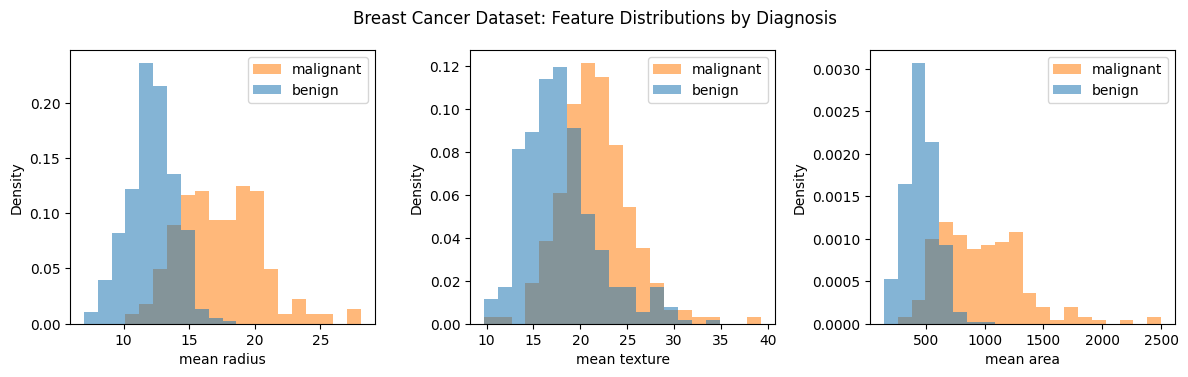

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, feature in zip(axes, ["mean radius", "mean texture", "mean area"]):
    values = data[feature].to_numpy()
    bins = np.linspace(values.min(), values.max(), 21)
    for label, color in [(0, "tab:orange"), (1, "tab:blue")]:
        ax.hist(values[breast_cancer.target == label], bins=bins,
                density=True, alpha=0.55, color=color,
                label=breast_cancer.target_names[label])
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend()
fig.suptitle("Breast Cancer Dataset: Feature Distributions by Diagnosis")
fig.tight_layout()
plt.show()

## 4. Splitting the data for training and testing
The test data is withheld from the initial GaussianNB fit. The fixed random seed makes this split reproducible; no stratification argument is added to the case-study-style split.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    breast_cancer.data, breast_cancer.target,
    random_state=11
)
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training targets:", y_train.shape)
print("Testing targets:", y_test.shape)

Training features: (426, 30)
Testing features: (143, 30)
Training targets: (426,)
Testing targets: (143,)


## 5. Creating the GaussianNB model
Gaussian Naive Bayes estimates class probabilities using a Gaussian distribution for each feature within each class. Its naive assumption is that features are conditionally independent given the class.

In [21]:
nb = GaussianNB()
print(nb)

GaussianNB()


## 6. Training the model

In [22]:
nb.fit(X_train, y_train)
print("Learned classes:", nb.classes_)
print("Training class counts:", nb.class_count_)
print("Training class priors:", nb.class_prior_)

Learned classes: [0 1]
Training class counts: [162. 264.]
Training class priors: [0.38028169 0.61971831]


## 7. Predicting test labels
Compare the predicted diagnoses with the actual labels, and list any incorrect predictions.

In [23]:
predicted = nb.predict(X_test)
expected = y_test
prediction_table = pd.DataFrame({
    "actual_label": expected,
    "predicted_label": predicted,
    "actual_diagnosis": breast_cancer.target_names[expected],
    "predicted_diagnosis": breast_cancer.target_names[predicted]
})
print("First 20 predictions:")
print(prediction_table.head(20).to_string(index=False))
incorrect = prediction_table.loc[expected != predicted]
print("\nIncorrect predictions:")
print(incorrect.to_string())
print("Number incorrect:", len(incorrect))

First 20 predictions:
 actual_label  predicted_label actual_diagnosis predicted_diagnosis
            0                0        malignant           malignant
            0                0        malignant           malignant
            0                0        malignant           malignant
            0                0        malignant           malignant
            0                0        malignant           malignant
            1                1           benign              benign
            0                0        malignant           malignant
            1                1           benign              benign
            1                1           benign              benign
            1                1           benign              benign
            1                1           benign              benign
            0                1        malignant              benign
            1                1           benign              benign
            1             

## 8. Estimator method score
For this classifier, score returns the fraction of correctly classified test samples.

In [24]:
test_accuracy = nb.score(X_test, y_test)
print(f"GaussianNB test accuracy: {test_accuracy:.6f} ({test_accuracy:.2%})")
print(f"Correct predictions: {(predicted == expected).sum()} / {len(expected)}")

GaussianNB test accuracy: 0.951049 (95.10%)
Correct predictions: 136 / 143


## 9. Confusion matrix
Rows are actual labels and columns are predicted labels, in the explicit order malignant (0), benign (1). The off-diagonal entries distinguish malignant samples predicted benign from benign samples predicted malignant.

In [25]:
confusion = confusion_matrix(y_true=expected, y_pred=predicted, labels=[0, 1])
print(pd.DataFrame(confusion,
    index=["Actual malignant (0)", "Actual benign (1)"],
    columns=["Predicted malignant (0)", "Predicted benign (1)"]).to_string())
print("Malignant predicted benign:", confusion[0, 1])
print("Benign predicted malignant:", confusion[1, 0])

                      Predicted malignant (0)  Predicted benign (1)
Actual malignant (0)                       44                     6
Actual benign (1)                           1                    92
Malignant predicted benign: 6
Benign predicted malignant: 1


## 10. Classification report
Precision measures the correctness of predictions for a class; recall measures how many actual members of that class were found. F1 is their harmonic mean, and support is the actual sample count. The report computes each class separately; malignant remains label 0 and is not silently relabeled as 1.

In [26]:
print(classification_report(
    y_true=expected, y_pred=predicted,
    labels=[0, 1], target_names=breast_cancer.target_names,
    digits=4, zero_division=0
))

              precision    recall  f1-score   support

   malignant     0.9778    0.8800    0.9263        50
      benign     0.9388    0.9892    0.9634        93

    accuracy                         0.9510       143
   macro avg     0.9583    0.9346    0.9448       143
weighted avg     0.9524    0.9510    0.9504       143



## 11. Visualizing the confusion matrix

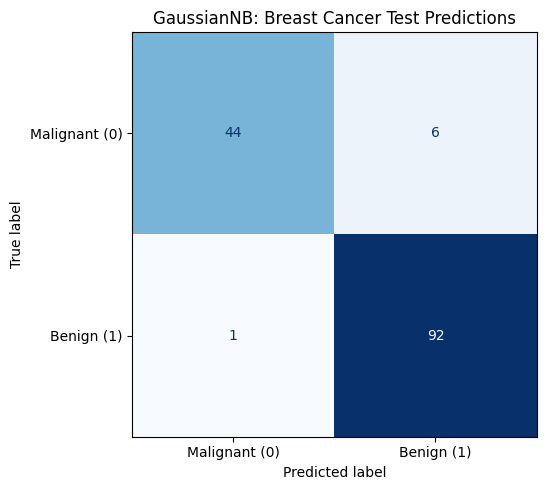

In [27]:
fig, ax = plt.subplots(figsize=(6.5, 5))
display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["Malignant (0)", "Benign (1)"]
)
display.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("GaussianNB: Breast Cancer Test Predictions")
fig.tight_layout()
plt.show()

## 12. K-fold cross-validation with the required KFold object
The full dataset is divided into ten folds after reproducible shuffling. Each fold is used once for validation, while the other nine folds train a fresh model. cross_val_score clones the estimator, so its earlier fitted state is not reused. This is the instructor's KFold configuration, not the stratified split selected by an integer cv=10.

In [28]:
kfold = KFold(n_splits=10, random_state=11, shuffle=True)
scores = cross_val_score(estimator=nb, X=breast_cancer.data,
                        y=breast_cancer.target, cv=kfold)
print("GaussianNB fold accuracies:", np.round(scores, 6))
print(f"Mean accuracy: {scores.mean():.6f} ({scores.mean():.2%})")
print(f"Standard deviation: {scores.std():.6f}")

GaussianNB fold accuracies: [0.964912 0.912281 0.947368 0.894737 0.964912 0.947368 0.964912 0.894737
 0.964912 0.928571]
Mean accuracy: 0.938471 (93.85%)
Standard deviation: 0.027503


## 13. Running multiple models to find the best one
All four models use the same data and shuffled folds. The ranking criterion is mean cross-validated accuracy. max_iter=10000 is an iteration limit, not a requirement to perform exactly that many iterations. The compatible LogisticRegression form below omits only the obsolete multi_class argument.

In [29]:
estimators = {
    'GaussianNB': nb,
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(solver='lbfgs', max_iter=10000),
    'SVC': SVC(gamma='scale')
}

model_rows = []
model_fold_scores = {}
for name, estimator in estimators.items():
    model_scores = cross_val_score(
        estimator=estimator, X=breast_cancer.data,
        y=breast_cancer.target, cv=kfold
    )
    model_fold_scores[name] = model_scores
    model_rows.append({"Model": name, "Mean accuracy": model_scores.mean(),
                       "Standard deviation": model_scores.std()})

comparison = pd.DataFrame(model_rows).sort_values(
    "Mean accuracy", ascending=False
).reset_index(drop=True)
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
best_model = comparison.loc[0, "Model"]
best_cv_accuracy = comparison.loc[0, "Mean accuracy"]
print(f"\nBest model in this comparison: {best_model} ({best_cv_accuracy:.2%})")

               Model  Mean accuracy  Standard deviation
  LogisticRegression       0.950815            0.030155
          GaussianNB       0.938471            0.027503
KNeighborsClassifier       0.927914            0.020055
                 SVC       0.919173            0.035227

Best model in this comparison: LogisticRegression (95.08%)


## 14. Consistency checks and results summary

In [30]:
assert breast_cancer.data.shape == (569, 30)
assert breast_cancer.target.shape == (569,)
assert len(X_train) + len(X_test) == 569
assert confusion.sum() == len(y_test)
assert np.isclose(np.trace(confusion) / confusion.sum(), test_accuracy)
assert len(scores) == 10 and len(model_fold_scores) == 4
np.testing.assert_allclose(scores, model_fold_scores["GaussianNB"])
print("Verification passed: sizes, accuracy, confusion matrix, and repeated CV results agree.")
print(f"\nGaussianNB classified {np.trace(confusion)} of {len(y_test)} test samples correctly.")
print(f"Test accuracy: {test_accuracy:.2%}; GaussianNB mean CV accuracy: {scores.mean():.2%}.")
print(f"Best compared model: {best_model}; mean CV accuracy: {best_cv_accuracy:.2%}.")

Verification passed: sizes, accuracy, confusion matrix, and repeated CV results agree.

GaussianNB classified 136 of 143 test samples correctly.
Test accuracy: 95.10%; GaussianNB mean CV accuracy: 93.85%.
Best compared model: LogisticRegression; mean CV accuracy: 95.08%.
